In [21]:
import os

os.makedirs("outputs", exist_ok=True)

print("Outputs folder ready!")

Outputs folder ready!


In [22]:
import os

os.makedirs("outputs", exist_ok=True)

print("Outputs folder created successfully!")

Outputs folder created successfully!


In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [14]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [15]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.info()

Train Shape: (77299, 11)
Test Shape: (41778, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [1]:
pip install pandas numpy scikit-learn lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


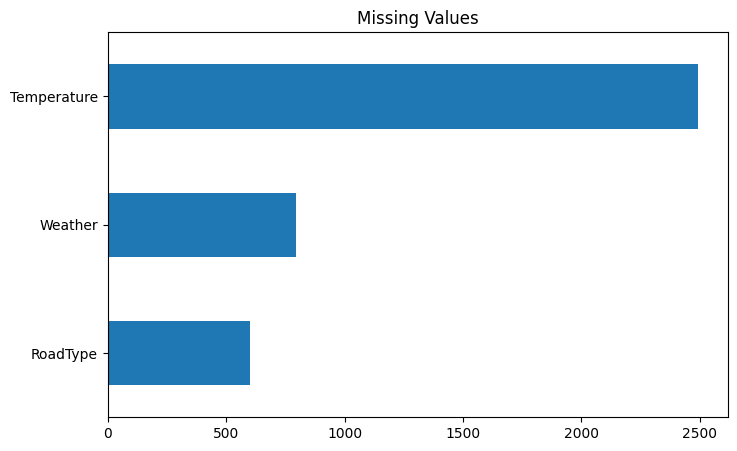

In [23]:
missing = train.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(8,5))

missing.sort_values().plot(
    kind="barh"
)

plt.title("Missing Values")

plt.savefig(
    "outputs/missing_values.png"
)

plt.show()

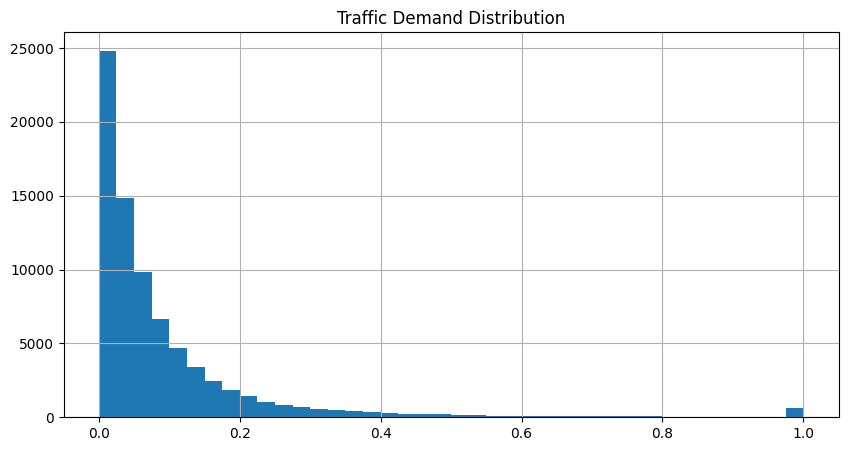

In [24]:
plt.figure(figsize=(10,5))

train["demand"].hist(
    bins=40
)

plt.title(
    "Traffic Demand Distribution"
)

plt.savefig(
    "outputs/demand_distribution.png"
)

plt.show()

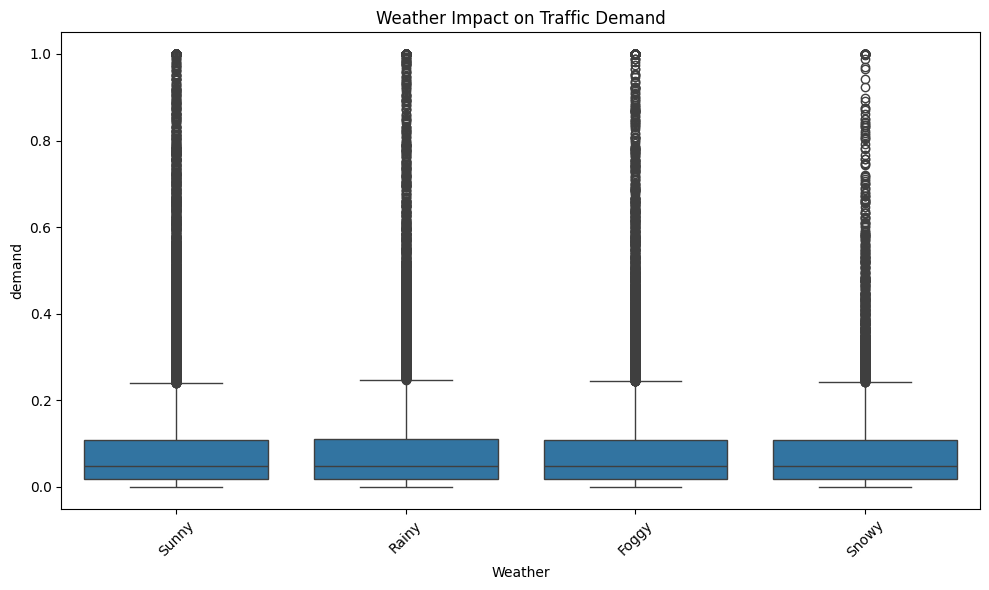

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Weather",
    y="demand",
    data=train
)

plt.xticks(rotation=45)

plt.title(
    "Weather Impact on Traffic Demand"
)

plt.tight_layout()

plt.savefig(
    "outputs/weather_impact.png"
)

plt.show()

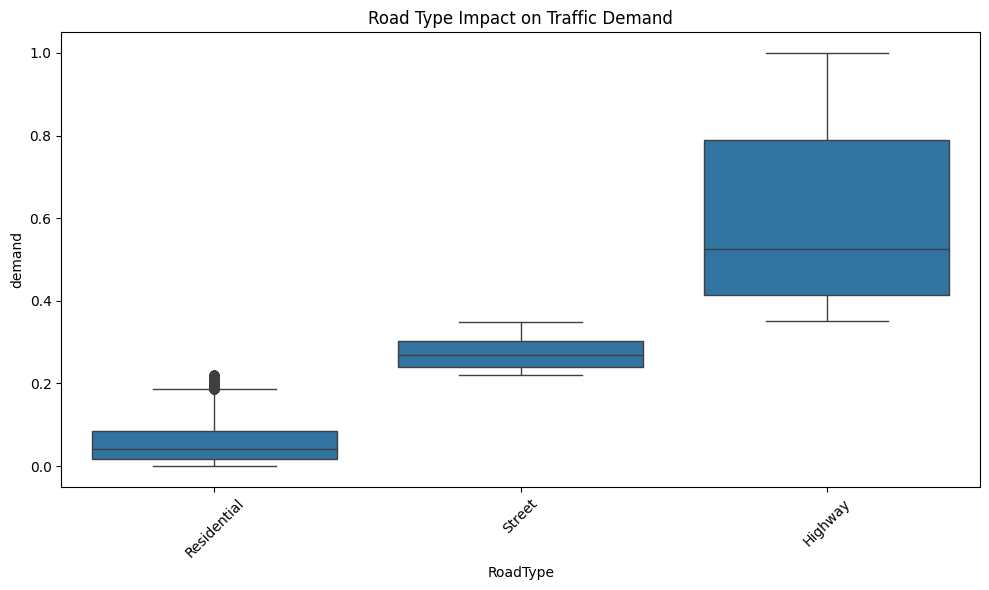

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="RoadType",
    y="demand",
    data=train
)

plt.xticks(rotation=45)

plt.title(
    "Road Type Impact on Traffic Demand"
)

plt.tight_layout()

plt.savefig(
    "outputs/roadtype_impact.png"
)

plt.show()

In [27]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 0.1397834	total: 141ms	remaining: 16m 26s
200:	learn: 0.0372023	total: 41.5s	remaining: 23m 25s
400:	learn: 0.0331444	total: 1m 25s	remaining: 23m 33s
600:	learn: 0.0310114	total: 2m 8s	remaining: 22m 45s
800:	learn: 0.0293375	total: 2m 49s	remaining: 21m 53s
1000:	learn: 0.0280997	total: 3m 36s	remaining: 21m 39s
1200:	learn: 0.0270563	total: 4m 28s	remaining: 21m 36s
1400:	learn: 0.0259859	total: 5m 26s	remaining: 21m 46s
1600:	learn: 0.0250312	total: 6m 29s	remaining: 21m 53s
1800:	learn: 0.0242095	total: 7m 38s	remaining: 22m 2s
2000:	learn: 0.0234553	total: 8m 47s	remaining: 21m 56s
2200:	learn: 0.0227532	total: 9m 59s	remaining: 21m 47s
2400:	learn: 0.0220627	total: 11m 15s	remaining: 21m 33s
2600:	learn: 0.0214207	total: 12m 35s	remaining: 21m 17s
2800:	learn: 0.0208189	total: 13m 59s	remaining: 20m 58s
3000:	learn: 0.0202443	total: 15m 28s	remaining: 20m 37s
3200:	learn: 0.0196768	total: 17m	remaining: 20m 10s
3400:	learn: 0.0191257	total: 18m 37s	remaining: 19m 42s
3

In [28]:
preds = model.predict(X_val)

print(
    "R2 Score:",
    r2_score(
        y_val,
        preds
    )
)

print(
    "MAE:",
    mean_absolute_error(
        y_val,
        preds
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_val,
            preds
        )
    )
)

R2 Score: 0.9493613873098611
MAE: 0.02059740992005064
RMSE: 0.03201009134754826


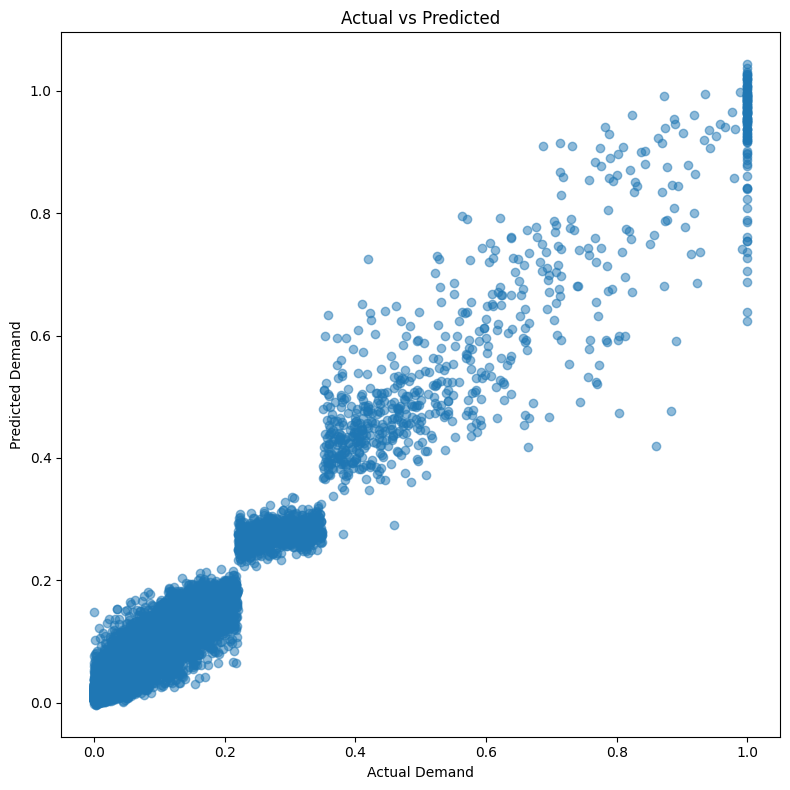

In [29]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_val,
    preds,
    alpha=0.5
)

plt.xlabel(
    "Actual Demand"
)

plt.ylabel(
    "Predicted Demand"
)

plt.title(
    "Actual vs Predicted"
)

plt.tight_layout()

plt.savefig(
    "outputs/actual_vs_predicted.png"
)

plt.show()

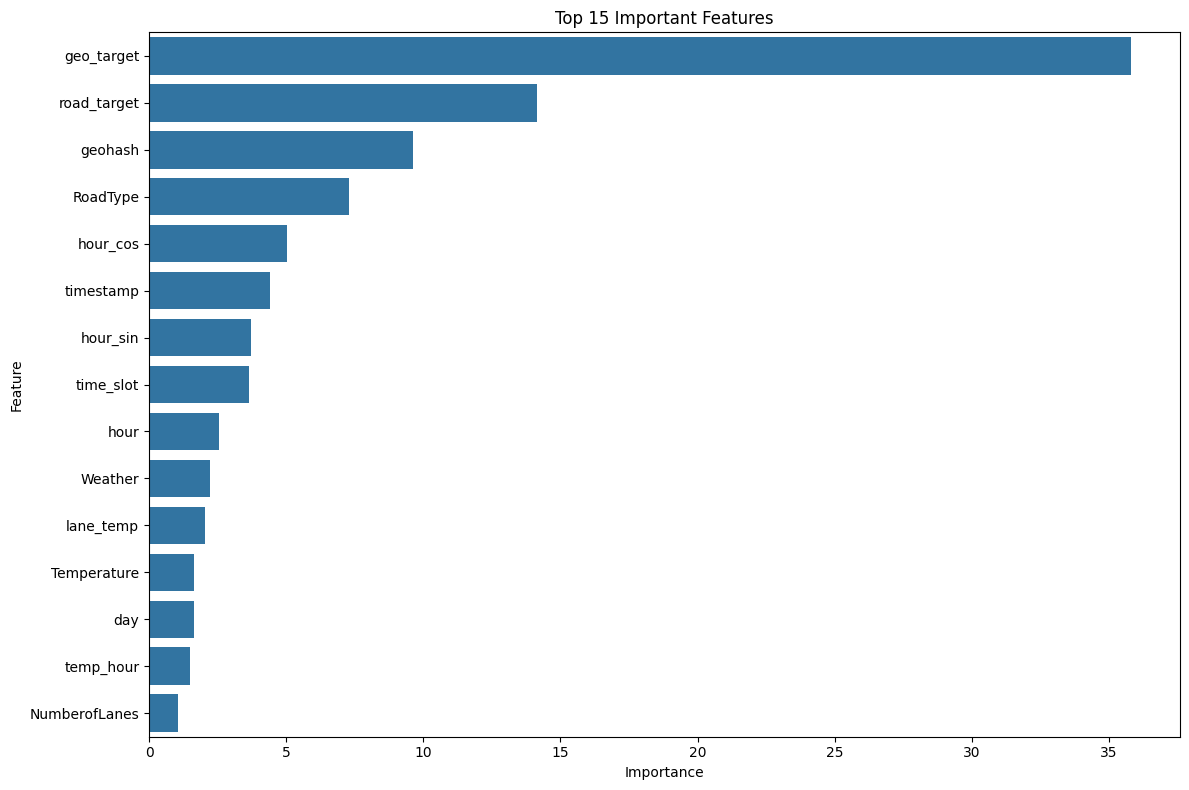

In [30]:
importance = model.get_feature_importance()

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.tight_layout()

plt.savefig(
    "outputs/feature_importance.png"
)

plt.show()

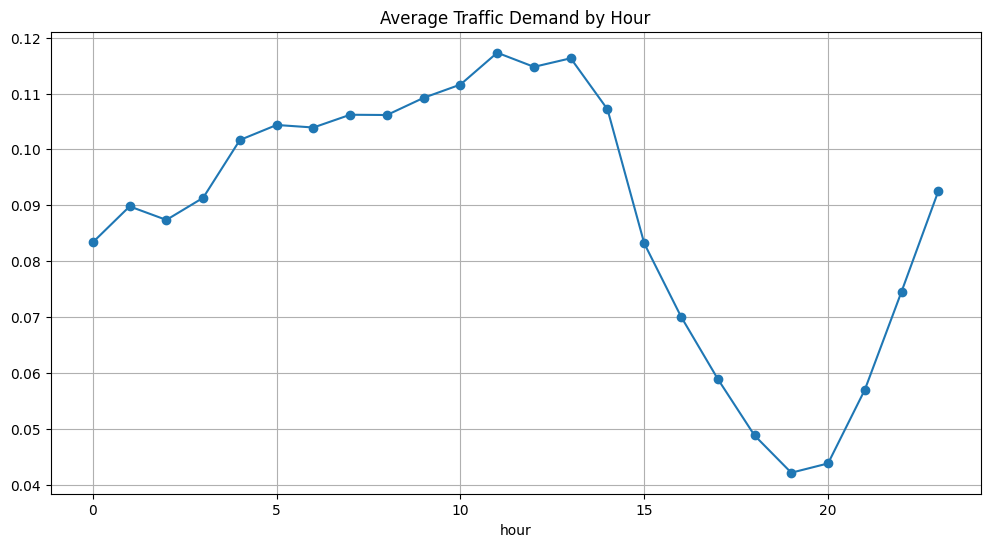

In [31]:
temp = train.copy()

time_split = temp["timestamp"].str.split(
    ":",
    expand=True
)

temp["hour"] = time_split[0].astype(int)

hourly = temp.groupby(
    "hour"
)["demand"].mean()

plt.figure(figsize=(12,6))

hourly.plot(
    marker="o"
)

plt.title(
    "Average Traffic Demand by Hour"
)

plt.grid(True)

plt.savefig(
    "outputs/hourly_traffic_pattern.png"
)

plt.show()

In [32]:
model.fit(
    X,
    y,
    cat_features=cat_features
)

predictions = model.predict(
    test_model
)

0:	learn: 0.1397208	total: 551ms	remaining: 1h 4m 18s
200:	learn: 0.0366718	total: 2m 4s	remaining: 1h 10m 8s
400:	learn: 0.0328636	total: 4m 17s	remaining: 1h 10m 44s
600:	learn: 0.0307003	total: 6m 31s	remaining: 1h 9m 26s
800:	learn: 0.0290485	total: 8m 41s	remaining: 1h 7m 14s
1000:	learn: 0.0279302	total: 10m 38s	remaining: 1h 3m 45s
1200:	learn: 0.0269028	total: 12m 45s	remaining: 1h 1m 36s
1400:	learn: 0.0259542	total: 14m 57s	remaining: 59m 48s
1600:	learn: 0.0251197	total: 17m 11s	remaining: 57m 58s
1800:	learn: 0.0243070	total: 19m 30s	remaining: 56m 17s
2000:	learn: 0.0235769	total: 21m 49s	remaining: 54m 31s
2200:	learn: 0.0229396	total: 24m 8s	remaining: 52m 39s
2400:	learn: 0.0223365	total: 26m 30s	remaining: 50m 46s
2600:	learn: 0.0217379	total: 28m 56s	remaining: 48m 56s
2800:	learn: 0.0211728	total: 31m 36s	remaining: 47m 22s
3000:	learn: 0.0206592	total: 34m 54s	remaining: 46m 31s
3200:	learn: 0.0201708	total: 38m 16s	remaining: 45m 25s
3400:	learn: 0.0196966	total: 4

In [33]:
from catboost import CatBoostRegressor

model.save_model(
    "trafficflow_ai_model.cbm"
)

print("Model saved successfully!")

Model saved successfully!


In [34]:
submission.to_csv(
    "submission.csv",
    index=False
)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

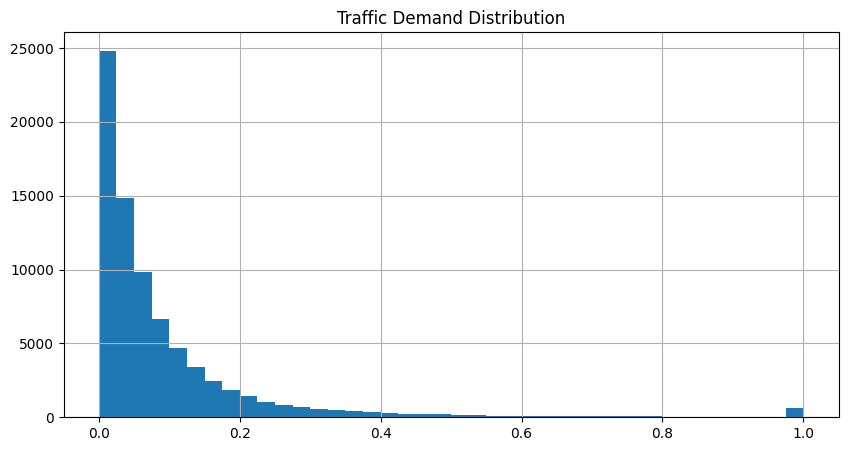

In [18]:
import os
import matplotlib.pyplot as plt

os.makedirs("outputs", exist_ok=True)

plt.figure(figsize=(10,5))

train["demand"].hist(bins=40)

plt.title("Traffic Demand Distribution")

plt.show()

In [7]:
pip install catboost pandas numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [9]:
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor

# ==================================
# LOAD DATA
# ==================================

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

test_ids = test["Index"]

# ==================================
# FEATURE ENGINEERING
# ==================================

def create_features(df):

    # timestamp features

    time_split = df["timestamp"].str.split(":", expand=True)

    df["hour"] = time_split[0].astype(int)
    df["minute"] = time_split[1].astype(int)

    df["time_slot"] = df["hour"] * 60 + df["minute"]

    df["is_peak"] = (
        (
            (df["hour"] >= 7)
            &
            (df["hour"] <= 10)
        )
        |
        (
            (df["hour"] >= 17)
            &
            (df["hour"] <= 20)
        )
    ).astype(int)

    df["hour_sin"] = np.sin(
        2 * np.pi * df["hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi * df["hour"] / 24
    )

    df["minute_sin"] = np.sin(
        2 * np.pi * df["minute"] / 60
    )

    df["minute_cos"] = np.cos(
        2 * np.pi * df["minute"] / 60
    )

    return df


train = create_features(train)
test = create_features(test)

# ==================================
# HANDLE MISSING VALUES
# ==================================

for col in ["RoadType", "Weather"]:

    train[col] = train[col].fillna("Missing")
    test[col] = test[col].fillna("Missing")

median_temp = train["Temperature"].median()

train["Temperature"] = train["Temperature"].fillna(
    median_temp
)

test["Temperature"] = test["Temperature"].fillna(
    median_temp
)

# ==================================
# TARGET ENCODING
# ==================================

global_mean = train["demand"].mean()

# geohash

geo_mean = train.groupby(
    "geohash"
)["demand"].mean()

train["geo_target"] = train["geohash"].map(
    geo_mean
)

test["geo_target"] = test["geohash"].map(
    geo_mean
)

test["geo_target"] = test["geo_target"].fillna(
    global_mean
)

# RoadType

road_mean = train.groupby(
    "RoadType"
)["demand"].mean()

train["road_target"] = train["RoadType"].map(
    road_mean
)

test["road_target"] = test["RoadType"].map(
    road_mean
)

test["road_target"] = test["road_target"].fillna(
    global_mean
)

# Weather

weather_mean = train.groupby(
    "Weather"
)["demand"].mean()

train["weather_target"] = train["Weather"].map(
    weather_mean
)

test["weather_target"] = test["Weather"].map(
    weather_mean
)

test["weather_target"] = test["weather_target"].fillna(
    global_mean
)

# ==================================
# INTERACTION FEATURES
# ==================================

train["temp_hour"] = (
    train["Temperature"]
    *
    train["hour"]
)

test["temp_hour"] = (
    test["Temperature"]
    *
    test["hour"]
)

train["lane_temp"] = (
    train["NumberofLanes"]
    *
    train["Temperature"]
)

test["lane_temp"] = (
    test["NumberofLanes"]
    *
    test["Temperature"]
)

# ==================================
# PREPARE DATA
# ==================================

TARGET = "demand"

X = train.drop(
    columns=[
        TARGET,
        "Index"
    ]
)

y = train[TARGET]

test_model = test.drop(
    columns=["Index"]
)

# ==================================
# CATEGORICAL FEATURES
# ==================================

cat_features = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "timestamp"
]

for col in cat_features:

    X[col] = X[col].astype(str)
    test_model[col] = test_model[col].astype(str)

# ==================================
# CATBOOST MODEL
# ==================================

model = CatBoostRegressor(
    iterations=7000,
    depth=12,
    learning_rate=0.02,
    loss_function="RMSE",
    l2_leaf_reg=5,
    bagging_temperature=1,
    random_seed=42,
    verbose=200
)

model.fit(
    X,
    y,
    cat_features=cat_features
)

# ==================================
# PREDICTION
# ==================================

predictions = model.predict(
    test_model
)

submission = pd.DataFrame({
    "Index": test_ids,
    "demand": predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv generated successfully")
print(submission.head())

0:	learn: 0.1397208	total: 180ms	remaining: 21m 1s
200:	learn: 0.0366718	total: 34.1s	remaining: 19m 13s
400:	learn: 0.0328636	total: 1m 11s	remaining: 19m 36s
600:	learn: 0.0307003	total: 1m 53s	remaining: 20m 4s
800:	learn: 0.0290485	total: 2m 33s	remaining: 19m 47s
1000:	learn: 0.0279302	total: 3m 10s	remaining: 18m 59s
1200:	learn: 0.0269028	total: 3m 48s	remaining: 18m 24s
1400:	learn: 0.0259542	total: 4m 30s	remaining: 17m 59s
1600:	learn: 0.0251197	total: 5m 11s	remaining: 17m 32s
1800:	learn: 0.0243070	total: 5m 56s	remaining: 17m 7s
2000:	learn: 0.0235769	total: 6m 44s	remaining: 16m 51s
2200:	learn: 0.0229396	total: 7m 34s	remaining: 16m 31s
2400:	learn: 0.0223365	total: 8m 27s	remaining: 16m 12s
2600:	learn: 0.0217379	total: 9m 18s	remaining: 15m 43s
2800:	learn: 0.0211728	total: 10m 8s	remaining: 15m 12s
3000:	learn: 0.0206592	total: 11m 1s	remaining: 14m 41s
3200:	learn: 0.0201708	total: 11m 56s	remaining: 14m 10s
3400:	learn: 0.0196966	total: 12m 50s	remaining: 13m 35s
36

In [12]:
hour
minute
hour_sin
hour_cos
minute_sin
minute_cos
is_peak

NameError: name 'hour' is not defined